# import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from sklearn.feature_selection import mutual_info_classif
from stoch_sim_model import *

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
runs = [100, 1_000, 1_000_0, 1_000_00, 1_000_000]

b_a1 = 2
t1 = 10
d_a1 = 3.8*10**(-4)
T_a1 = 10

MI_b_a1 = np.zeros((len(runs),len(stat_names)))

run_count = 0

for run in runs:
    b_a1s = np.random.uniform(0.1*b_a1, 10*b_a1, size = run) 
    t1s = [t1]
    d_a1s = [d_a1]
    T_a1s = [T_a1]

    run_data_b_a1 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(b_a1s)/8))(delayed(sum_sim)(b_a1, t1, d_a1, T_a1)
                                                  for b_a1 in b_a1s
                                                  for t1 in t1s
                                                  for d_a1 in d_a1s
                                                  for T_a1 in T_a1s))
    
    for i in range(run_data_b_a1.shape[1]):
        MI_b_a1[run_count, i] = calc_MI(run_data_b_a1[:,0],run_data_b_a1[:,i])
    
    run_count += 1
    

[]

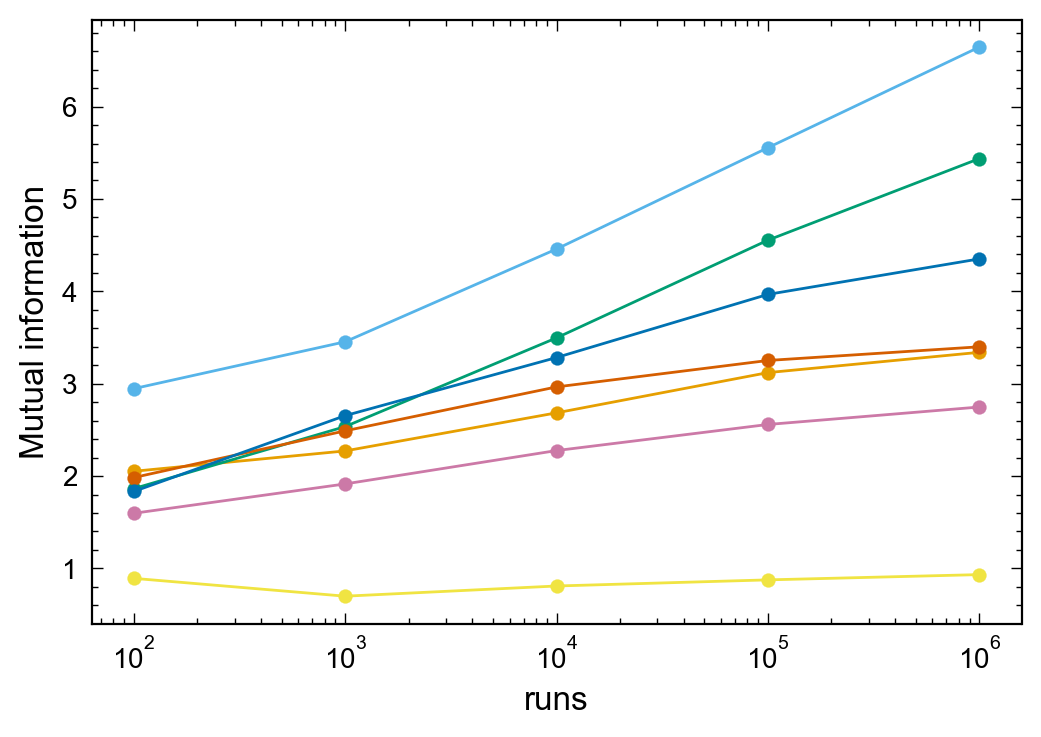

In [3]:
plt.plot(runs, MI_b_a1[:,np.hstack(([0],np.arange(4,10)))], 'o-')
plt.xlabel("runs")
plt.ylabel("Mutual information")
plt.semilogx()

[]

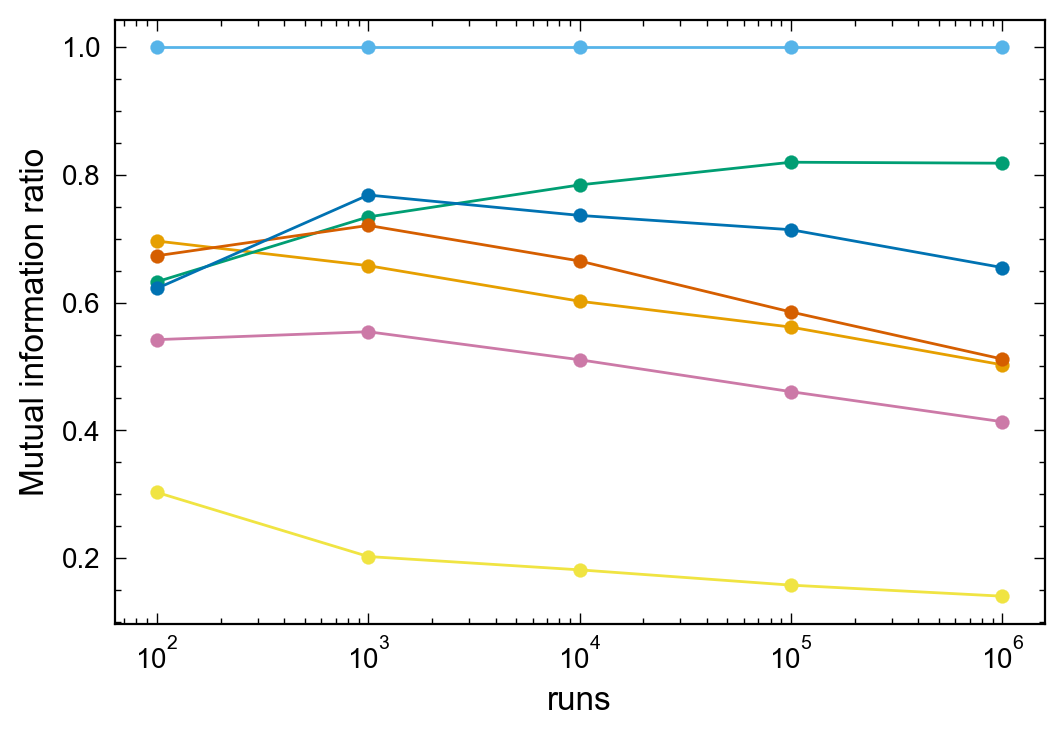

In [4]:
MI_b_a1_frac = np.zeros((len(runs),len(stat_names)))
for i in np.arange(len(runs)):
    MI_b_a1_frac[i,:] = MI_b_a1[i,:]/MI_b_a1[i,0]
 

plt.plot(runs, MI_b_a1_frac[:,np.hstack(([0],np.arange(4,10)))], 'o-')
plt.xlabel("runs")
plt.ylabel("Mutual information ratio")
plt.semilogx()